# IBM AML 패턴 외 자금세탁 계좌 이력 피처 제거 실험 v4

이 노트북은 기존 small_eda2.ipynb에 이어 붙이지 않고 독립적으로 실행할 수 있도록 작성했습니다.

목표는 계좌·거래쌍의 과거 행동 피처를 전부 제거했을 때 패턴 외 자금세탁 탐지 성능이 얼마나 달라지는지 확인하는 것입니다. v3와 데이터, 시간 분할, 학습 표본 구성과 모델을 동일하게 유지하고 이력 피처 사용 여부만 비교합니다.


## 실험 정의

- 양성 1: Is Laundering이 1이면서 Patterns.txt에 없는 거래
- 음성 0: Is Laundering이 0인 정상거래
- 학습 제외: Patterns.txt에 포함된 자금세탁 거래
- 분석 기간: 2022-09-01부터 2022-09-10까지
- Reinvestment: 시뮬레이션 초기 잔액 성격이므로 기본적으로 제외
- Patterns.txt 안에 Is Laundering이 0인 거래가 있더라도 역할을 추정하지 않고 원본 정상 라벨을 유지
- 금액: 데이터에서 확인한 고정환율로 모든 통화를 USD로 환산
- 학습 제외 피처: Payment Format, 원본 Timestamp, 날짜, 요일, 주말 여부
- 사용 시간 피처: 하루 안의 시각을 나타내는 hour_sin, hour_cos만 사용
- 제거 이력 피처: sender_prev_count_log, receiver_prev_count_log, pair_prev_count_log, hours_since_sender_prev_log, amount_vs_sender_history_usd
- 시간 분할: 학습 1~7일, 검증 8일, 테스트 9~10일

v3 대비 성능이 크게 하락하면 계좌 이력 피처가 구분 신호에 기여한 것이고, 거의 같으면 추가 정보가 적다고 해석합니다. Small 데이터는 최종 결론보다 실험 절차를 확인하는 용도로 사용합니다.


In [1]:
# 추가 패키지 설치 없이 scikit-learn만 사용합니다.

In [2]:
import csv
import gc
import shutil
import warnings
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')


## 1. 데이터 경로와 실행 옵션

small_eda2.ipynb와 동일하게 현재 작업 폴더 아래 datasets 폴더를 사용합니다. MODEL_RATIO를 HI 또는 LI로 바꾸면 해당 데이터셋을 학습합니다. 이 실험에서는 계좌 이력 피처 제거가 목적이므로 USE_CAUSAL_HISTORY_FEATURES를 False로 고정합니다.


In [3]:
MODEL_RATIO = 'HI'  # LI를 분석하려면 'LI'로 변경
RATIOS = [MODEL_RATIO]  # 메모리를 아끼기 위해 한 번에 한 데이터셋만 로드
SIZE = 'Small'

EXCLUDE_REINVESTMENT = True
USE_CAUSAL_HISTORY_FEATURES = False  # v4: 계좌·거래쌍 과거 이력 피처 전부 제거
NEGATIVE_SAMPLE_RATIO = 10  # 학습 양성 1건당 정상거래 10건

PRIMARY_END = pd.Timestamp('2022-09-11 00:00')
TRAIN_END = pd.Timestamp('2022-09-08 00:00')
VALID_END = pd.Timestamp('2022-09-09 00:00')

DATASET_HANDLE = (
    'ealtman2019/'
    'ibm-transactions-for-anti-money-laundering-aml'
)

DATA_DIR = Path.cwd() / 'datasets'
DATA_DIR.mkdir(parents=True, exist_ok=True)

print('현재 작업 폴더:', Path.cwd())
print('데이터 저장 폴더:', DATA_DIR)
print('모델링 대상:', f'{MODEL_RATIO}-{SIZE}')


현재 작업 폴더: /workspace/money_laundry
데이터 저장 폴더: /workspace/money_laundry/datasets
모델링 대상: HI-Small


## 2. 필요한 파일 다운로드

이번 기준 실험에는 거래 파일과 패턴 파일만 사용합니다. accounts.csv의 엔티티 피처는 기준 모델을 확인한 뒤 추가하는 편이 좋습니다.


In [4]:
import kagglehub

wanted_files = []
for ratio in RATIOS:
    wanted_files.extend([
        f'{ratio}-{SIZE}_Trans.csv',
        f'{ratio}-{SIZE}_Patterns.txt',
    ])

for filename in wanted_files:
    destination = DATA_DIR / filename

    if destination.exists():
        print('이미 존재하므로 건너뜀:', destination.name)
        continue

    print('다운로드 시작:', filename)
    downloaded_path = Path(
        kagglehub.dataset_download(
            DATASET_HANDLE,
            path=filename,
        )
    )
    shutil.copy2(downloaded_path, destination)
    print('다운로드 완료:', destination)


이미 존재하므로 건너뜀: HI-Small_Trans.csv
이미 존재하므로 건너뜀: HI-Small_Patterns.txt


In [5]:
dataset_paths = {}

for ratio in RATIOS:
    dataset_paths[ratio] = {
        'transactions': DATA_DIR / f'{ratio}-{SIZE}_Trans.csv',
        'patterns': DATA_DIR / f'{ratio}-{SIZE}_Patterns.txt',
    }

for ratio, paths in dataset_paths.items():
    print(f'\n===== {ratio}-{SIZE} =====')
    for file_type, path in paths.items():
        if not path.exists():
            raise FileNotFoundError(f'파일이 없습니다: {path}')
        print(f'{file_type:<15}: {path.name}')



===== HI-Small =====
transactions   : HI-Small_Trans.csv
patterns       : HI-Small_Patterns.txt


## 3. Patterns.txt 파싱 함수

Patterns.txt의 BEGIN과 END 사이 거래를 읽고 Attempt ID와 Pattern Type을 붙입니다. 이 정보는 패턴 소속 거래를 학습 데이터에서 제외하는 데 사용합니다.


In [6]:
TRANSACTION_COLUMNS = [
    'Timestamp',
    'From Bank',
    'Account',
    'To Bank',
    'Account.1',
    'Amount Received',
    'Receiving Currency',
    'Amount Paid',
    'Payment Currency',
    'Payment Format',
    'Is Laundering',
]

ID_COLUMNS = ['From Bank', 'Account', 'To Bank', 'Account.1']
AMOUNT_COLUMNS = ['Amount Received', 'Amount Paid']
TEXT_COLUMNS = [
    'Receiving Currency',
    'Payment Currency',
    'Payment Format',
]

def parse_pattern_file(path, ratio):
    # 거래 한 행당 하나의 레코드로 변환합니다.
    records = []
    current = None
    attempt_number = 0
    transaction_order = 0

    with open(path, mode='r', encoding='utf-8', errors='replace') as file:
        for line_number, raw_line in enumerate(file, start=1):
            line = raw_line.strip()
            if not line:
                continue

            begin_prefix = 'BEGIN LAUNDERING ATTEMPT - '
            end_prefix = 'END LAUNDERING ATTEMPT - '

            if line.startswith(begin_prefix):
                if current is not None:
                    raise ValueError(f'{line_number}행: attempt 중첩')

                attempt_number += 1
                pattern_text = line[len(begin_prefix):].strip()
                parts = pattern_text.split(':', maxsplit=1)
                current = {
                    'Dataset': ratio,
                    'Attempt ID': f'{ratio}_{attempt_number:04d}',
                    'Attempt Number': attempt_number,
                    'Pattern Type': parts[0].strip().upper(),
                    'Pattern Meta': parts[1].strip() if len(parts) == 2 else '',
                }
                transaction_order = 0
                continue

            if line.startswith(end_prefix):
                if current is None:
                    raise ValueError(f'{line_number}행: BEGIN 없는 END')

                end_type = line[len(end_prefix):].strip().upper()
                if end_type != current['Pattern Type']:
                    raise ValueError(
                        f'{line_number}행: BEGIN/END 패턴 불일치'
                    )
                current = None
                transaction_order = 0
                continue

            if current is None:
                raise ValueError(f'{line_number}행: attempt 밖의 거래')

            values = next(csv.reader(StringIO(line)))
            if len(values) != len(TRANSACTION_COLUMNS):
                raise ValueError(
                    f'{line_number}행의 컬럼 수가 {len(values)}개입니다.'
                )

            transaction_order += 1
            records.append({
                **current,
                'Transaction Order': transaction_order,
                **dict(zip(TRANSACTION_COLUMNS, values)),
            })

    if current is not None:
        raise ValueError('마지막 attempt에 END가 없습니다.')

    return pd.DataFrame(records)


## 4. 거래와 패턴 데이터 로드 및 타입 통일

패턴 거래를 정확히 찾으려면 Timestamp, 계좌 ID, 금액, 라벨의 타입이 Trans.csv와 Patterns.txt에서 같아야 합니다. 이 단계가 다르면 모든 거래가 패턴 외로 잘못 분류될 수 있습니다.


In [7]:
transaction_dtypes = {column: 'string' for column in ID_COLUMNS}

def normalize_transaction_types(df):
    # 두 파일에 동일한 변환 규칙을 적용합니다.
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='raise')

    for column in ID_COLUMNS:
        df[column] = df[column].astype('string')

    for column in AMOUNT_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors='raise')

    for column in TEXT_COLUMNS:
        df[column] = df[column].astype('string')

    df['Is Laundering'] = (
        pd.to_numeric(df['Is Laundering'], errors='raise')
        .astype('int8')
    )
    return df

transactions = {}
pattern_transactions = {}

for ratio in RATIOS:
    print(f'\n{ratio}-{SIZE} 거래 로드 중...')
    trans = pd.read_csv(
        dataset_paths[ratio]['transactions'],
        dtype=transaction_dtypes,
        low_memory=False,
    )
    trans = normalize_transaction_types(trans)

    before = len(trans)
    trans = trans.drop_duplicates().reset_index(drop=True)
    print(f'완전 중복 제거: {before - len(trans):,}건')

    patterns = parse_pattern_file(
        dataset_paths[ratio]['patterns'],
        ratio,
    )
    patterns = normalize_transaction_types(patterns)

    transactions[ratio] = trans
    pattern_transactions[ratio] = patterns

    print('거래 행 수:', f'{len(trans):,}')
    print('패턴 거래 행 수:', f'{len(patterns):,}')
    print('패턴 Attempt 수:', patterns['Attempt ID'].nunique())



HI-Small 거래 로드 중...
완전 중복 제거: 9건
거래 행 수: 5,078,336
패턴 거래 행 수: 3,209
패턴 Attempt 수: 370


## 5. 패턴 소속 여부와 모델 클래스 생성

거래의 11개 원본 컬럼을 해시해 Trans.csv와 Patterns.txt를 비교합니다. 타입을 먼저 통일했기 때문에 날짜 문자열 형식이나 ID 타입 차이로 인한 오분류를 줄일 수 있습니다.


In [8]:
EXPECTED_COUNTS = {
    'HI': {'laundering': 5177, 'pattern': 3209, 'outside': 1968},
    'LI': {'laundering': 3565, 'pattern': 1023, 'outside': 2542},
}

classification_summary = {}

for ratio in RATIOS:
    trans = transactions[ratio]
    patterns = pattern_transactions[ratio]

    pattern_hashes = set(
        pd.util.hash_pandas_object(
            patterns[TRANSACTION_COLUMNS],
            index=False,
        ).astype('uint64')
    )

    trans_hashes = pd.util.hash_pandas_object(
        trans[TRANSACTION_COLUMNS],
        index=False,
    ).astype('uint64')

    trans['is_pattern_transaction'] = trans_hashes.isin(pattern_hashes)

    is_laundering = trans['Is Laundering'].eq(1)
    is_pattern = trans['is_pattern_transaction'] & is_laundering
    is_pattern_label0 = trans['is_pattern_transaction'] & (~is_laundering)
    is_outside = (~trans['is_pattern_transaction']) & is_laundering

    trans['class_name'] = np.select(
        [is_pattern, is_outside],
        ['pattern_laundering', 'outside_laundering'],
        default='normal',
    )

    summary = {
        '전체 거래': len(trans),
        '전체 자금세탁': int(is_laundering.sum()),
        '패턴 파일 전체 거래': int(trans['is_pattern_transaction'].sum()),
        '패턴 자금세탁': int(is_pattern.sum()),
        '패턴 내 0 라벨 거래': int(is_pattern_label0.sum()),
        '패턴 외 자금세탁': int(is_outside.sum()),
        '정상거래': int((~is_laundering).sum()),
    }
    classification_summary[ratio] = summary

    expected = EXPECTED_COUNTS[ratio]
    observed = (
        summary['전체 자금세탁'],
        summary['패턴 자금세탁'],
        summary['패턴 외 자금세탁'],
    )
    expected_tuple = (
        expected['laundering'],
        expected['pattern'],
        expected['outside'],
    )
    if observed != expected_tuple:
        warnings.warn(
            f'{ratio} 집계가 기존 확인값과 다릅니다: '
            f'{observed} != {expected_tuple}'
        )

display(pd.DataFrame(classification_summary).T)


,전체 거래,전체 자금세탁,패턴 파일 전체 거래,패턴 자금세탁,패턴 내 0 라벨 거래,패턴 외 자금세탁,정상거래
HI,5078336,5177,3209,3209,0,1968,5073159


In [9]:
# 날짜별로 세 클래스의 건수를 확인합니다.
for ratio in RATIOS:
    temp = transactions[ratio].copy()
    temp['date'] = temp['Timestamp'].dt.date

    daily = pd.crosstab(temp['date'], temp['class_name'])
    print(f'\n===== {ratio}-{SIZE} 날짜별 클래스 =====')
    display(daily)

    del temp
gc.collect()



===== HI-Small 날짜별 클래스 =====


class_name,normal,outside_laundering,pattern_laundering
date,,,
2022-09-01,1114597,228,94
2022-09-02,754041,238,170
2022-09-03,206991,190,201
2022-09-04,207023,157,250
2022-09-05,482179,195,276
2022-09-06,481558,210,321
2022-09-07,482253,168,329
2022-09-08,482232,211,328
2022-09-09,653949,216,298


20

## 6. 모델링 기간 선택과 피처 생성

11일 이후 생성기 꼬리 구간은 제외합니다. 패턴 자금세탁은 모델의 양성이나 음성으로 사용하지 않습니다. v4에서는 과거 행동 피처를 계산하지 않으므로 패턴 거래의 이력 포함 여부도 모델 입력에 영향을 주지 않습니다.

USD 금액, 은행·계좌 관계, 통화와 하루 안의 시각처럼 현재 거래 한 건에서 바로 계산할 수 있는 피처만 사용합니다.


In [10]:
# 기준: 1 US Dollar = 해당 통화 수량
UNITS_PER_USD = {
    'US Dollar': 1.0,
    'Euro': 0.8534,
    'Swiss Franc': 0.9150,
    'UK Pound': 0.7742,
    'Yuan': 6.6976,
    'Yen': 105.4000,
    'Rupee': 73.4440,
    'Ruble': 77.8040,
    'Shekel': 3.3770,
    'Saudi Riyal': 3.7511,
    'Canadian Dollar': 1.3193,
    'Australian Dollar': 1.4128,
    'Mexican Peso': 21.1431,
    'Brazil Real': 5.6465,
    'Bitcoin': 0.0000841611,
}

def add_transaction_features(df):
    # 거래 한 건 자체에서 알 수 있는 피처입니다.
    result = df  # 입력 history_df가 이미 복사본이므로 제자리에서 피처 추가

    paid_rate = result['Payment Currency'].map(UNITS_PER_USD)
    received_rate = result['Receiving Currency'].map(UNITS_PER_USD)
    if paid_rate.isna().any() or received_rate.isna().any():
        missing = set(result.loc[paid_rate.isna(), 'Payment Currency'])
        missing |= set(result.loc[received_rate.isna(), 'Receiving Currency'])
        raise ValueError(f'환율표에 없는 통화: {sorted(missing)}')

    # 원본 금액은 보존하고 USD 환산 금액을 별도 컬럼으로 만듭니다.
    result['amount_paid_usd'] = result['Amount Paid'] / paid_rate
    result['amount_received_usd'] = result['Amount Received'] / received_rate
    result['log_amount_paid_usd'] = np.log1p(
        result['amount_paid_usd'].clip(lower=0)
    )
    result['log_amount_received_usd'] = np.log1p(
        result['amount_received_usd'].clip(lower=0)
    )
    result['log_amount_ratio_usd'] = np.log(
        (result['amount_received_usd'].clip(lower=0) + 1e-9)
        / (result['amount_paid_usd'].clip(lower=0) + 1e-9)
    )

    result['is_cross_bank'] = (
        result['From Bank'].ne(result['To Bank']).astype('int8')
    )
    result['is_self_transfer'] = (
        result['From Bank'].eq(result['To Bank'])
        & result['Account'].eq(result['Account.1'])
    ).astype('int8')
    result['is_cross_currency'] = (
        result['Payment Currency'].ne(result['Receiving Currency'])
        .astype('int8')
    )

    hour = result['Timestamp'].dt.hour + result['Timestamp'].dt.minute / 60
    result['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    result['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    # 정확한 날짜·요일은 넣지 않고 하루 안의 시각만 순환값으로 표현합니다.

    return result

def add_causal_history_features(df):
    # 이 함수는 Small 전체 거래를 정렬하므로 시간과 메모리가 필요합니다.
    result = df
    result['_original_order'] = np.arange(len(result), dtype=np.int64)
    result['_source_node'] = (
        result['From Bank'].astype('string') + '::' + result['Account'].astype('string')
    )
    result['_target_node'] = (
        result['To Bank'].astype('string') + '::' + result['Account.1'].astype('string')
    )

    result = result.sort_values(
        ['Timestamp', '_original_order'],
        kind='mergesort',
    )

    sender_group = result.groupby('_source_node', sort=False)
    receiver_group = result.groupby('_target_node', sort=False)

    sender_prev_count = sender_group.cumcount()
    receiver_prev_count = receiver_group.cumcount()
    pair_prev_count = result.groupby(
        ['_source_node', '_target_node'],
        sort=False,
    ).cumcount()

    # 현재 거래를 제외한 과거 USD 환산 송금액 평균입니다.
    sender_cumulative_paid = sender_group['amount_paid_usd'].cumsum()
    sender_previous_sum = sender_cumulative_paid - result['amount_paid_usd']
    sender_previous_mean = (
        sender_previous_sum
        / sender_prev_count.replace(0, np.nan)
    )

    hours_since_sender_previous = (
        sender_group['Timestamp'].diff().dt.total_seconds() / 3600
    )

    result['sender_prev_count_log'] = np.log1p(sender_prev_count)
    result['receiver_prev_count_log'] = np.log1p(receiver_prev_count)
    result['pair_prev_count_log'] = np.log1p(pair_prev_count)
    result['hours_since_sender_prev_log'] = np.log1p(
        hours_since_sender_previous.clip(lower=0)
    )
    result['amount_vs_sender_history_usd'] = (
        result['log_amount_paid_usd']
        - np.log1p(sender_previous_mean.clip(lower=0))
    )

    result = result.sort_values('_original_order', kind='mergesort')
    result = result.drop(
        columns=['_original_order', '_source_node', '_target_node']
    )
    return result


In [11]:
# 선택한 HI 또는 LI 데이터만 모델 피처를 계산합니다.
history_df = transactions[MODEL_RATIO].loc[
    transactions[MODEL_RATIO]['Timestamp'].lt(PRIMARY_END)
].copy()

# 원본 전체 DataFrame은 이후 사용하지 않으므로 메모리에서 해제합니다.
transactions.clear()
pattern_transactions.clear()
gc.collect()

if EXCLUDE_REINVESTMENT:
    before = len(history_df)
    history_df = history_df.loc[
        history_df['Payment Format'].ne('Reinvestment')
    ].copy()
    print('Reinvestment 제외:', f'{before - len(history_df):,}건')

history_df = add_transaction_features(history_df)

if USE_CAUSAL_HISTORY_FEATURES:
    print('과거 계좌 행동 피처 계산 중...')
    history_df = add_causal_history_features(history_df)
else:
    print('v4: 계좌·거래쌍 과거 이력 피처를 계산하지 않습니다.')

# 패턴 자금세탁은 학습에서 제외합니다.
model_df = history_df.loc[
    history_df['class_name'].isin(['normal', 'outside_laundering'])
].copy()
model_df['target'] = model_df['class_name'].eq('outside_laundering').astype('int8')
del history_df
gc.collect()

print('모델링 전체 행 수:', f'{len(model_df):,}')
print('양성 행 수:', f'{model_df["target"].sum():,}')
display(model_df.head())


Reinvestment 제외: 481,056건
v4: 계좌·거래쌍 과거 이력 피처를 계산하지 않습니다.
모델링 전체 행 수: 4,593,618
양성 행 수: 1,968


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,is_pattern_transaction,class_name,amount_paid_usd,amount_received_usd,log_amount_paid_usd,log_amount_received_usd,log_amount_ratio_usd,is_cross_bank,is_self_transfer,is_cross_currency,hour_sin,hour_cos,target
1,2022-09-01 00:20:00,03208,8000F4580,001,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,False,normal,0.01,0.01,0.009950,0.009950,0.0,1,0,0,0.087156,0.996195,0
8,2022-09-01 00:26:00,012,8000EC280,002439,8017BF800,7.66,US Dollar,7.66,US Dollar,Credit Card,0,False,normal,7.66,7.66,2.158715,2.158715,0.0,1,0,0,0.113203,0.993572,0
9,2022-09-01 00:21:00,001,8000EDEC0,0211050,80AEF5310,383.71,US Dollar,383.71,US Dollar,Credit Card,0,False,normal,383.71,383.71,5.952490,5.952490,0.0,1,0,0,0.091502,0.995805,0
10,2022-09-01 00:04:00,001,8000F4510,011813,8011305D0,9.82,US Dollar,9.82,US Dollar,Credit Card,0,False,normal,9.82,9.82,2.381396,2.381396,0.0,1,0,0,0.017452,0.999848,0
12,2022-09-01 00:08:00,001,8000F4FE0,0245335,812ED62E0,4.01,US Dollar,4.01,US Dollar,Credit Card,0,False,normal,4.01,4.01,1.611436,1.611436,0.0,1,0,0,0.034899,0.999391,0


## 7. 시간 기준 학습·검증·테스트 분할

무작위 분할을 사용하지 않습니다. 미래 거래가 학습에 들어가지 않도록 날짜 순서대로 나눕니다. 테스트 데이터의 정상거래는 줄이지 않고 원래 불균형 비율을 유지합니다.


In [12]:
model_df['split'] = np.select(
    [
        model_df['Timestamp'].lt(TRAIN_END),
        model_df['Timestamp'].lt(VALID_END),
    ],
    ['train', 'valid'],
    default='test',
)

split_summary = pd.crosstab(
    model_df['split'],
    model_df['class_name'],
).reindex(['train', 'valid', 'test'])
display(split_summary)

daily_summary = pd.crosstab(
    model_df['Timestamp'].dt.date,
    model_df['class_name'],
)
daily_summary['outside_rate_per_100k'] = (
    daily_summary.get('outside_laundering', 0)
    / daily_summary.sum(axis=1)
    * 100_000
)
display(daily_summary)


class_name,normal,outside_laundering
split,,
train,3247586,1386
valid,482232,211
test,861832,371


class_name,normal,outside_laundering,outside_rate_per_100k
Timestamp,,,
2022-09-01,633541,228,35.975253
2022-09-02,754041,238,31.553311
2022-09-03,206991,190,91.707251
2022-09-04,207023,157,75.779515
2022-09-05,482179,195,40.425064
2022-09-06,481558,210,43.589446
2022-09-07,482253,168,34.824355
2022-09-08,482232,211,43.735737
2022-09-09,653949,216,33.019192


## 8. 학습 전 간단한 피처 비교

모델 점수 전에 USD 환산 금액과 현재 거래 자체의 특성을 비교합니다. v4에서는 계좌 행동 이력 피처를 계산하지 않습니다. Payment Format은 학습 피처에서 제외하며, 큰 정상 클래스는 그래프에서 최대 10만 건만 표본으로 사용합니다.


In [13]:
comparison_columns = [
    'log_amount_paid_usd',
    'log_amount_received_usd',
    'log_amount_ratio_usd',
    'is_cross_bank',
    'is_self_transfer',
    'is_cross_currency',
]

if USE_CAUSAL_HISTORY_FEATURES:
    comparison_columns += [
        'sender_prev_count_log',
        'receiver_prev_count_log',
        'pair_prev_count_log',
        'hours_since_sender_prev_log',
        'amount_vs_sender_history_usd',
    ]

print('클래스별 중앙값')
display(model_df.groupby('class_name')[comparison_columns].median().T)

print('클래스별 통화 비율')
currency_ratio = pd.crosstab(
    model_df['class_name'],
    model_df['Payment Currency'],
    normalize='index',
).mul(100).round(2)
display(currency_ratio)


클래스별 중앙값


class_name,normal,outside_laundering
log_amount_paid_usd,6.783535,7.775215
log_amount_received_usd,6.783535,7.775215
log_amount_ratio_usd,0.000000,0.000000
is_cross_bank,1.000000,1.000000
is_self_transfer,0.000000,0.000000
is_cross_currency,0.000000,0.000000


클래스별 통화 비율


Payment Currency,Australian Dollar,Bitcoin,Brazil Real,Canadian Dollar,Euro,Mexican Peso,Ruble,Rupee,Saudi Riyal,Shekel,Swiss Franc,UK Pound,US Dollar,Yen,Yuan
class_name,,,,,,,,,,,,,,,
normal,2.70,3.18,1.39,2.76,22.87,2.16,3.06,3.74,1.75,3.78,4.61,3.57,37.17,3.05,4.21
outside_laundering,2.95,2.79,1.83,2.64,24.70,1.98,3.10,2.85,1.93,3.56,4.01,3.10,37.30,3.35,3.91


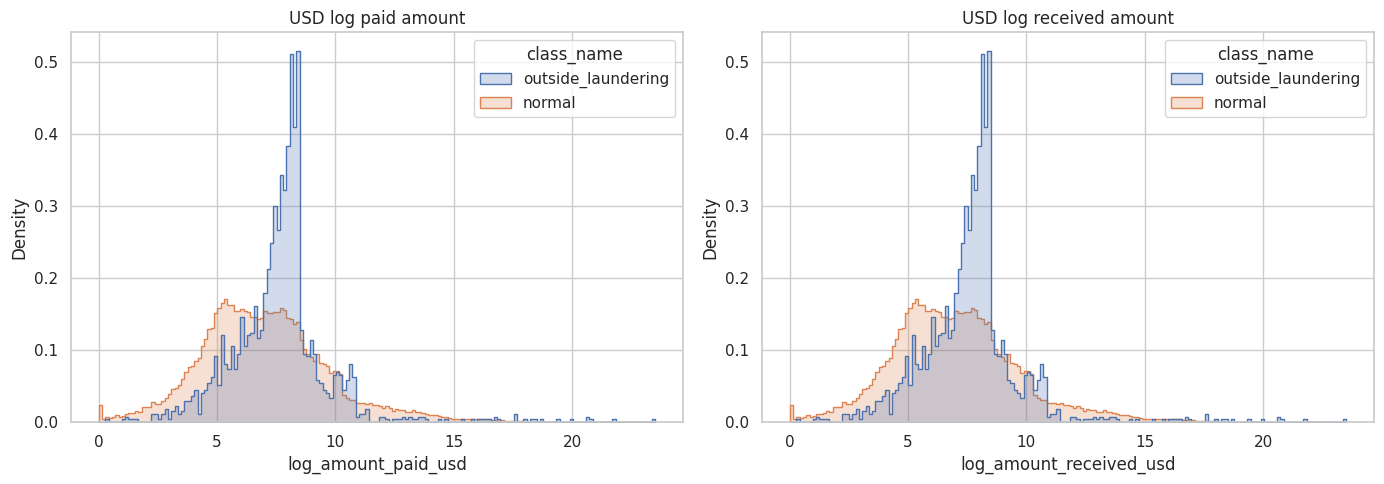

In [14]:
positive_plot = model_df.loc[model_df['target'].eq(1)]
negative_pool = model_df.loc[model_df['target'].eq(0)]
negative_plot = negative_pool.sample(
    n=min(100_000, len(negative_pool)),
    random_state=RANDOM_STATE,
)
plot_sample = pd.concat([positive_plot, negative_plot], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(
    data=plot_sample,
    x='log_amount_paid_usd',
    hue='class_name',
    stat='density',
    common_norm=False,
    element='step',
    ax=axes[0],
)
axes[0].set_title('USD log paid amount')

sns.histplot(
    data=plot_sample,
    x='log_amount_received_usd',
    hue='class_name',
    stat='density',
    common_norm=False,
    element='step',
    ax=axes[1],
)
axes[1].set_title('USD log received amount')
plt.tight_layout()
plt.show()


## 9. 학습용 정상거래 표본 구성

학습에서만 정상거래를 줄입니다. 검증과 테스트는 실제 클래스 비율을 유지해야 실제 환경에서 Precision과 PR-AUC를 해석할 수 있습니다.


In [15]:
train_full = model_df.loc[model_df['split'].eq('train')].copy()
valid_df = model_df.loc[model_df['split'].eq('valid')].copy()
test_df = model_df.loc[model_df['split'].eq('test')].copy()
del model_df
gc.collect()

train_positive = train_full.loc[train_full['target'].eq(1)]
train_negative = train_full.loc[train_full['target'].eq(0)]
negative_n = min(
    len(train_negative),
    len(train_positive) * NEGATIVE_SAMPLE_RATIO,
)
sampled_negative = train_negative.sample(
    n=negative_n,
    random_state=RANDOM_STATE,
)

train_df = pd.concat(
    [train_positive, sampled_negative],
    ignore_index=True,
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

del train_full, train_positive, train_negative, sampled_negative
gc.collect()

print('학습 표본')
display(train_df['target'].value_counts().sort_index().to_frame('count'))
print('검증 원래 비율')
display(valid_df['target'].value_counts().sort_index().to_frame('count'))
print('테스트 원래 비율')
display(test_df['target'].value_counts().sort_index().to_frame('count'))


학습 표본


,count
target,
0,13860
1,1386


검증 원래 비율


,count
target,
0,482232
1,211


테스트 원래 비율


,count
target,
0,861832
1,371


## 10. 모델 피처와 전처리

계좌번호와 Entity ID 자체는 넣지 않습니다. Payment Format과 정확한 날짜·요일·주말도 넣지 않습니다. 원본 Timestamp는 시간 분할에만 사용하고 모델에는 시각의 순환값만 제공합니다. 계좌·거래쌍 과거 횟수, 직전 거래 이후 시간과 과거 평균 대비 금액은 모두 제외합니다. 범주형 통화는 One-Hot Encoding, 숫자형 값은 결측치 처리와 표준화를 적용합니다.


In [16]:
BASE_NUMERIC_FEATURES = [
    'log_amount_paid_usd',
    'log_amount_received_usd',
    'log_amount_ratio_usd',
    'is_cross_bank',
    'is_self_transfer',
    'is_cross_currency',
    'hour_sin',
    'hour_cos',
]

HISTORY_FEATURES = [
    'sender_prev_count_log',
    'receiver_prev_count_log',
    'pair_prev_count_log',
    'hours_since_sender_prev_log',
    'amount_vs_sender_history_usd',
]

CATEGORICAL_FEATURES = [
    'Payment Currency',
    'Receiving Currency',
]

NUMERIC_FEATURES = BASE_NUMERIC_FEATURES.copy()
if USE_CAUSAL_HISTORY_FEATURES:
    NUMERIC_FEATURES += HISTORY_FEATURES

# v4에서는 과거 이력 피처가 모델 입력에 하나도 남지 않았는지 검증합니다.
assert USE_CAUSAL_HISTORY_FEATURES is False
assert set(HISTORY_FEATURES).isdisjoint(NUMERIC_FEATURES)

FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

def make_preprocessor(numeric_features, categorical_features):
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])

    return ColumnTransformer([
        ('num', numeric_pipe, numeric_features),
        ('cat', categorical_pipe, categorical_features),
    ])

print('제거된 계좌 이력 피처:', HISTORY_FEATURES)
print('숫자형 피처:', NUMERIC_FEATURES)
print('범주형 피처:', CATEGORICAL_FEATURES)


제거된 계좌 이력 피처: ['sender_prev_count_log', 'receiver_prev_count_log', 'pair_prev_count_log', 'hours_since_sender_prev_log', 'amount_vs_sender_history_usd']
숫자형 피처: ['log_amount_paid_usd', 'log_amount_received_usd', 'log_amount_ratio_usd', 'is_cross_bank', 'is_self_transfer', 'is_cross_currency', 'hour_sin', 'hour_cos']
범주형 피처: ['Payment Currency', 'Receiving Currency']


## 11. 평가 함수

정확도 대신 PR-AUC, Precision, Recall, F1을 봅니다. 분류 임계값은 테스트가 아니라 검증 데이터에서 F1이 가장 높은 값으로 선택합니다. Precision@K는 조사 우선순위 상위 K건 중 실제 양성 비율을 보여줍니다.


In [17]:
def best_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    if len(thresholds) == 0:
        return 0.5

    f1_values = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-12)
    )
    return float(thresholds[np.nanargmax(f1_values)])

def precision_recall_at_k(y_true, scores, k):
    k = min(k, len(scores))
    top_index = np.argsort(-scores)[:k]
    top_true = np.asarray(y_true)[top_index]
    precision_at_k = top_true.mean() if k else np.nan
    recall_at_k = top_true.sum() / max(np.asarray(y_true).sum(), 1)
    return precision_at_k, recall_at_k

def evaluate_model(model, valid_data, test_data, feature_columns):
    valid_scores = model.predict_proba(valid_data[feature_columns])[:, 1]
    threshold = best_f1_threshold(valid_data['target'], valid_scores)

    test_scores = model.predict_proba(test_data[feature_columns])[:, 1]
    test_pred = (test_scores >= threshold).astype('int8')
    y_test = test_data['target'].to_numpy()

    metrics = {
        'threshold': threshold,
        'PR-AUC': average_precision_score(y_test, test_scores),
        'precision': precision_score(y_test, test_pred, zero_division=0),
        'recall': recall_score(y_test, test_pred, zero_division=0),
        'F1': f1_score(y_test, test_pred, zero_division=0),
    }

    for k in [100, 500, 1000]:
        p_at_k, r_at_k = precision_recall_at_k(y_test, test_scores, k)
        metrics[f'precision@{k}'] = p_at_k
        metrics[f'recall@{k}'] = r_at_k

    print('Confusion matrix')
    display(pd.DataFrame(
        confusion_matrix(y_test, test_pred),
        index=['actual_0', 'actual_1'],
        columns=['pred_0', 'pred_1'],
    ))

    return metrics, test_scores


## 12. Logistic Regression 기준 모델

복잡한 모델 전에 선형 기준 모델을 먼저 확인합니다. 이 모델의 목적은 높은 최종 성능보다 어떤 방향의 피처가 양성과 연관되는지 확인하는 것입니다.


In [18]:
logistic_model = Pipeline([
    ('preprocess', make_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES)),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

logistic_model.fit(train_df[FEATURE_COLUMNS], train_df['target'])

logistic_metrics, logistic_test_scores = evaluate_model(
    logistic_model,
    valid_df,
    test_df,
    FEATURE_COLUMNS,
)
display(pd.Series(logistic_metrics, name='Logistic Regression').to_frame())


Confusion matrix


,pred_0,pred_1
actual_0,509741,352091
actual_1,148,223


,Logistic Regression
threshold,0.501616
PR-AUC,0.000524
precision,0.000633
recall,0.601078
F1,0.001265
precision@100,0.000000
recall@100,0.000000
precision@500,0.002000
recall@500,0.002695
precision@1000,0.001000


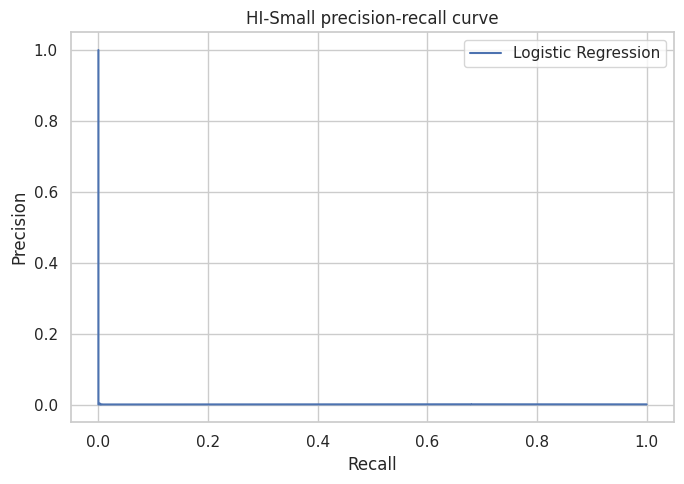

In [19]:
# 테스트 PR 곡선
test_precision, test_recall, _ = precision_recall_curve(
    test_df['target'],
    logistic_test_scores,
)

plt.figure(figsize=(7, 5))
plt.plot(test_recall, test_precision, label='Logistic Regression')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'{MODEL_RATIO}-{SIZE} precision-recall curve')
plt.legend()
plt.tight_layout()
plt.show()


In [20]:
# 양의 계수는 패턴 외 자금세탁 확률을 높이는 방향입니다.
feature_names = (
    logistic_model.named_steps['preprocess']
    .get_feature_names_out()
)
coefficients = logistic_model.named_steps['model'].coef_[0]
coefficient_table = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
}).sort_values('coefficient', ascending=False)

print('양성과 강하게 연결된 피처')
display(coefficient_table.head(20))
print('정상거래와 강하게 연결된 피처')
display(coefficient_table.tail(20).sort_values('coefficient'))


양성과 강하게 연결된 피처


,feature,coefficient
10,cat__Payment Currency_Brazil Real,0.272761
25,cat__Receiving Currency_Brazil Real,0.272204
0,num__log_amount_paid_usd,0.146403
1,num__log_amount_received_usd,0.146402
3,num__is_cross_bank,0.095552
37,cat__Receiving Currency_Yuan,0.053488
22,cat__Payment Currency_Yuan,0.050534
17,cat__Payment Currency_Shekel,0.034250
32,cat__Receiving Currency_Shekel,0.033026
21,cat__Payment Currency_Yen,0.030815


정상거래와 강하게 연결된 피처


,feature,coefficient
4,num__is_self_transfer,-0.750506
5,num__is_cross_currency,-0.373576
28,cat__Receiving Currency_Mexican Peso,-0.175775
13,cat__Payment Currency_Mexican Peso,-0.174504
31,cat__Receiving Currency_Saudi Riyal,-0.084679
16,cat__Payment Currency_Saudi Riyal,-0.084073
33,cat__Receiving Currency_Swiss Franc,-0.083331
18,cat__Payment Currency_Swiss Franc,-0.081544
19,cat__Payment Currency_UK Pound,-0.070179
34,cat__Receiving Currency_UK Pound,-0.070051


## 13. Random Forest 비선형 모델

금액과 계좌 행동의 비선형 관계를 확인하기 위한 두 번째 모델입니다. 추가 패키지 없이 Small 학습 표본에서 실행할 수 있습니다.


In [21]:
random_forest_model = Pipeline([
    ('preprocess', make_preprocessor(NUMERIC_FEATURES, CATEGORICAL_FEATURES)),
    ('model', RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

random_forest_model.fit(train_df[FEATURE_COLUMNS], train_df['target'])

random_forest_metrics, random_forest_test_scores = evaluate_model(
    random_forest_model,
    valid_df,
    test_df,
    FEATURE_COLUMNS,
)

model_comparison = pd.DataFrame({
    'Logistic Regression': logistic_metrics,
    'Random Forest': random_forest_metrics,
}).T
display(model_comparison)


Confusion matrix


,pred_0,pred_1
actual_0,854180,7652
actual_1,354,17


,threshold,PR-AUC,precision,recall,F1,precision@100,recall@100,precision@500,recall@500,precision@1000,recall@1000
Logistic Regression,0.501616,0.000524,0.000633,0.601078,0.001265,0.0,0.0,0.002,0.002695,0.001,0.002695
Random Forest,0.691223,0.001092,0.002217,0.045822,0.004229,0.0,0.0,0.002,0.002695,0.003,0.008086


,feature,importance
0,num__log_amount_paid_usd,0.271552
1,num__log_amount_received_usd,0.266672
6,num__hour_sin,0.178357
7,num__hour_cos,0.176384
3,num__is_cross_bank,0.008030
4,num__is_self_transfer,0.007786
20,cat__Payment Currency_US Dollar,0.005664
35,cat__Receiving Currency_US Dollar,0.005617
27,cat__Receiving Currency_Euro,0.005370
12,cat__Payment Currency_Euro,0.005361


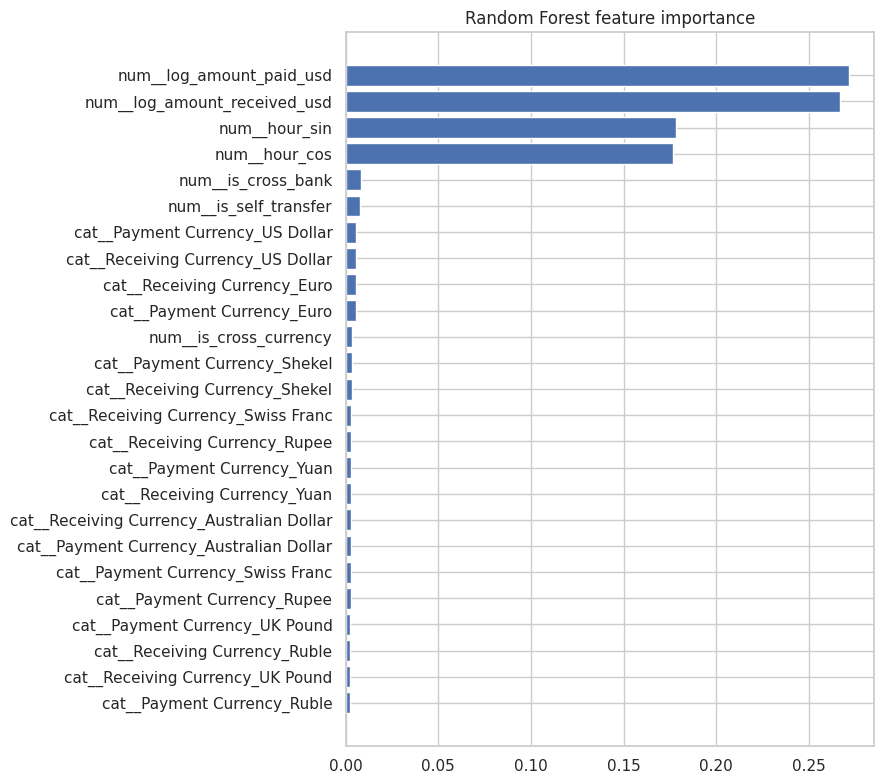

In [22]:
random_forest_feature_names = (
    random_forest_model.named_steps['preprocess']
    .get_feature_names_out()
)
importance_table = pd.DataFrame({
    'feature': random_forest_feature_names,
    'importance': random_forest_model.named_steps['model'].feature_importances_,
}).sort_values('importance', ascending=False)

display(importance_table.head(30))

plt.figure(figsize=(9, 8))
top_importance = importance_table.head(25).sort_values('importance')
plt.barh(top_importance['feature'], top_importance['importance'])
plt.title('Random Forest feature importance')
plt.tight_layout()
plt.show()


## 14. 통화 식별자 의존 여부 확인

USD 환산 금액만으로도 성능이 유지되는지 보기 위해 통화 이름과 교차통화 여부를 제거한 Logistic Regression을 한 번 더 학습합니다.


In [23]:
ABLATION_NUMERIC_FEATURES = [
    feature for feature in NUMERIC_FEATURES
    if feature != 'is_cross_currency'
]
ABLATION_CATEGORICAL_FEATURES = [
    feature for feature in CATEGORICAL_FEATURES
    if feature not in ['Payment Currency', 'Receiving Currency']
]
ABLATION_FEATURE_COLUMNS = (
    ABLATION_NUMERIC_FEATURES + ABLATION_CATEGORICAL_FEATURES
)

ablation_model = Pipeline([
    ('preprocess', make_preprocessor(
        ABLATION_NUMERIC_FEATURES,
        ABLATION_CATEGORICAL_FEATURES,
    )),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])

ablation_model.fit(
    train_df[ABLATION_FEATURE_COLUMNS],
    train_df['target'],
)
ablation_metrics, _ = evaluate_model(
    ablation_model,
    valid_df,
    test_df,
    ABLATION_FEATURE_COLUMNS,
)

display(pd.DataFrame({
    '통화 정보 포함 Logistic': logistic_metrics,
    '통화 정보 제거 Logistic': ablation_metrics,
}).T)


Confusion matrix


,pred_0,pred_1
actual_0,495568,366264
actual_1,116,255


,threshold,PR-AUC,precision,recall,F1,precision@100,recall@100,precision@500,recall@500,precision@1000,recall@1000
통화 정보 포함 Logistic,0.501616,0.000524,0.000633,0.601078,0.001265,0.0,0.0,0.002,0.002695,0.001,0.002695
통화 정보 제거 Logistic,0.499000,0.000544,0.000696,0.687332,0.001390,0.0,0.0,0.002,0.002695,0.001,0.002695


## 15. v3 기준값과 v4 결과 비교

v3와 v4는 데이터, 타깃, 시간 분할, 정상거래 표본과 모델 설정이 같습니다. v4에서 제거한 것은 다음 다섯 개 이력 피처입니다.

- sender_prev_count_log
- receiver_prev_count_log
- pair_prev_count_log
- hours_since_sender_prev_log
- amount_vs_sender_history_usd

해석 순서는 다음과 같습니다.

1. v3와 학습·검증·테스트 표본 수가 같은지 확인합니다.
2. PR-AUC와 Precision@K, Recall@K가 얼마나 달라졌는지 확인합니다.
3. v4 성능이 크게 하락하면 계좌 이력 피처가 구분 신호에 기여한 것입니다.
4. 거의 같으면 현재 이력 피처의 추가 정보가 적다는 뜻입니다.
5. 오히려 상승하면 이력 피처가 노이즈나 Small 데이터 과적합을 만들었을 가능성이 있습니다.
6. Threshold 한 지점뿐 아니라 PR-AUC와 여러 K의 순위 성능을 함께 비교합니다.


In [24]:
V3_REFERENCE = {
    'v3 Logistic': {
        'threshold': 0.953739,
        'PR-AUC': 0.002464,
        'precision': 0.001960,
        'recall': 0.051213,
        'F1': 0.003776,
        'precision@100': 0.000000,
        'recall@100': 0.000000,
        'precision@500': 0.002000,
        'recall@500': 0.002695,
        'precision@1000': 0.001000,
        'recall@1000': 0.002695,
    },
    'v3 Random Forest': {
        'threshold': 0.901086,
        'PR-AUC': 0.006797,
        'precision': 0.008264,
        'recall': 0.026954,
        'F1': 0.012650,
        'precision@100': 0.000000,
        'recall@100': 0.000000,
        'precision@500': 0.006000,
        'recall@500': 0.008086,
        'precision@1000': 0.009000,
        'recall@1000': 0.024259,
    },
    'v3 통화 제거 Logistic': {
        'threshold': 0.951934,
        'PR-AUC': 0.002478,
        'precision': 0.002139,
        'recall': 0.056604,
        'F1': 0.004122,
        'precision@100': 0.000000,
        'recall@100': 0.000000,
        'precision@500': 0.002000,
        'recall@500': 0.002695,
        'precision@1000': 0.001000,
        'recall@1000': 0.002695,
    },
}

v4_results = {
    'v4 Logistic': logistic_metrics,
    'v4 Random Forest': random_forest_metrics,
    'v4 통화 제거 Logistic': ablation_metrics,
}

comparison_columns = [
    'threshold',
    'PR-AUC',
    'precision',
    'recall',
    'F1',
    'precision@100',
    'recall@100',
    'precision@500',
    'recall@500',
    'precision@1000',
    'recall@1000',
]

v3_v4_comparison = pd.DataFrame({
    **V3_REFERENCE,
    **v4_results,
}).T[comparison_columns]

display(v3_v4_comparison)


,threshold,PR-AUC,precision,recall,F1,precision@100,recall@100,precision@500,recall@500,precision@1000,recall@1000
v3 Logistic,0.953739,0.002464,0.001960,0.051213,0.003776,0.0,0.0,0.002,0.002695,0.001,0.002695
v3 Random Forest,0.901086,0.006797,0.008264,0.026954,0.012650,0.0,0.0,0.006,0.008086,0.009,0.024259
v3 통화 제거 Logistic,0.951934,0.002478,0.002139,0.056604,0.004122,0.0,0.0,0.002,0.002695,0.001,0.002695
v4 Logistic,0.501616,0.000524,0.000633,0.601078,0.001265,0.0,0.0,0.002,0.002695,0.001,0.002695
v4 Random Forest,0.691223,0.001092,0.002217,0.045822,0.004229,0.0,0.0,0.002,0.002695,0.003,0.008086
v4 통화 제거 Logistic,0.499000,0.000544,0.000696,0.687332,0.001390,0.0,0.0,0.002,0.002695,0.001,0.002695
